# Milestone 1 — Medical EDA

UCI Chronic Kidney Disease dataset.
Goal: understand feature distributions, missingness patterns, and comorbidity structure
before preprocessing. The held-out `classification` label is used for context only — never
fed into the clustering pipeline.


In [1]:
import sys; sys.path.append('..')
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path

from src.data_loader import load_ckd
from src.preprocessing import clean_types, NUMERIC_COLS, BINARY_COLS, encode_binary, BINARY_ENCODING
from src import viz

sns.set_theme(style='whitegrid')
FIGDIR = Path('../reports/figures'); FIGDIR.mkdir(parents=True, exist_ok=True)


## 1. Load + clean types

In [2]:
df_raw = load_ckd('../data/raw/kidney_disease.csv')
df = clean_types(df_raw)
print(df.shape)
df.head()

(400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


## 2. Missingness analysis

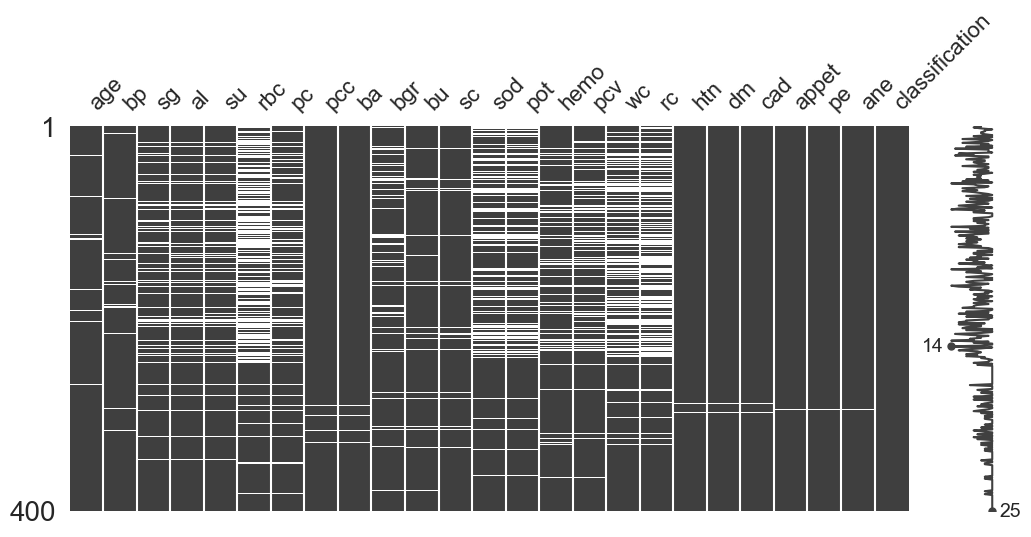

In [3]:
msno.matrix(df, figsize=(12, 5))
plt.savefig(FIGDIR / 'missingness_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

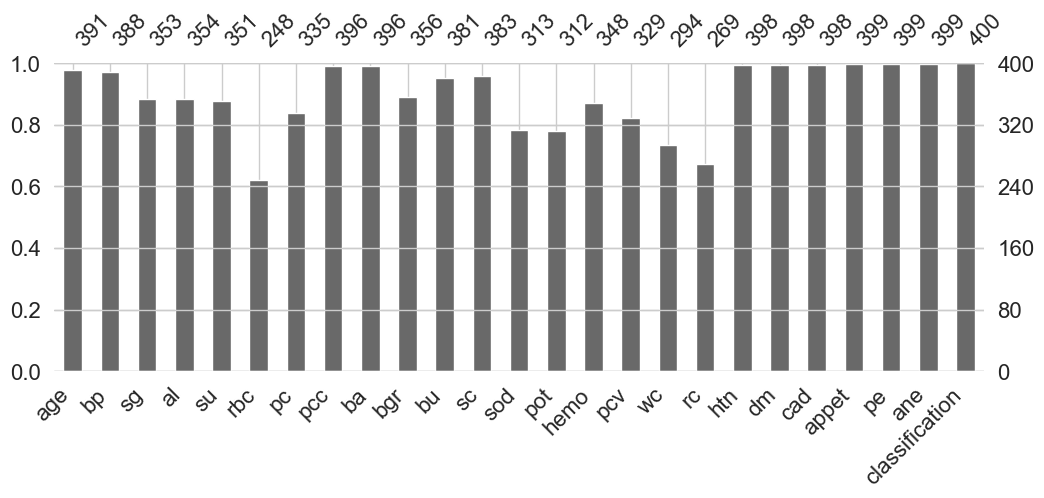

In [4]:
msno.bar(df, figsize=(12, 4))
plt.savefig(FIGDIR / 'missingness_bar.png', dpi=150, bbox_inches='tight')
plt.show()

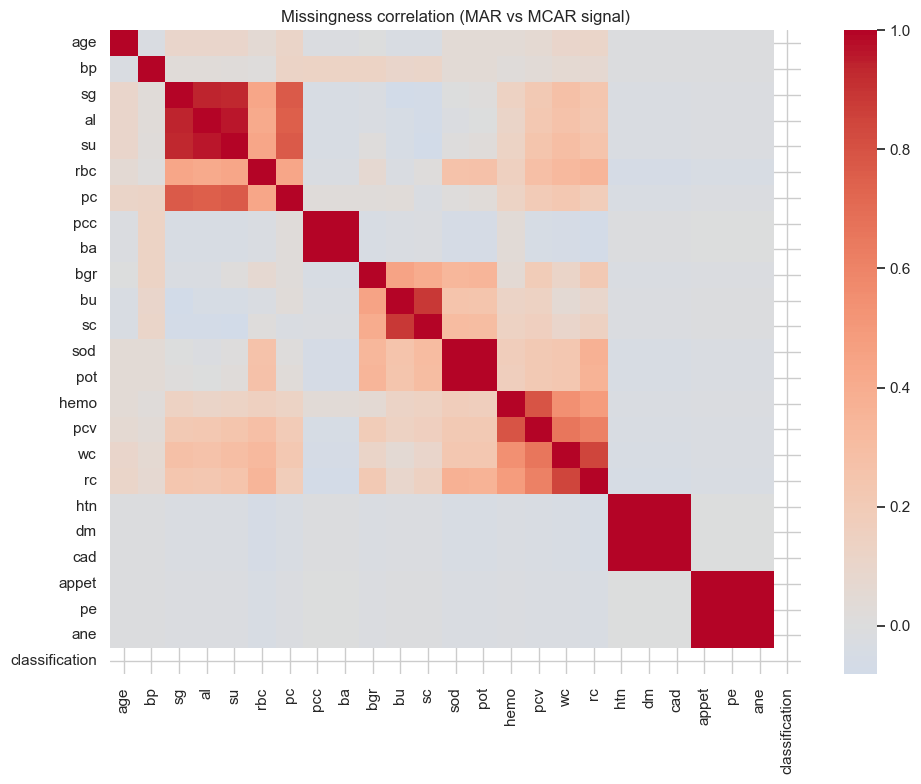

In [5]:
# Missingness correlation: are features missing together?
miss = df.isna().astype(int)
miss_corr = miss.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(miss_corr, cmap='coolwarm', center=0)
plt.title('Missingness correlation (MAR vs MCAR signal)')
plt.tight_layout()
plt.savefig(FIGDIR / 'missingness_correlation.png', dpi=150)
plt.show()

## 3. Univariate distributions stratified by age group

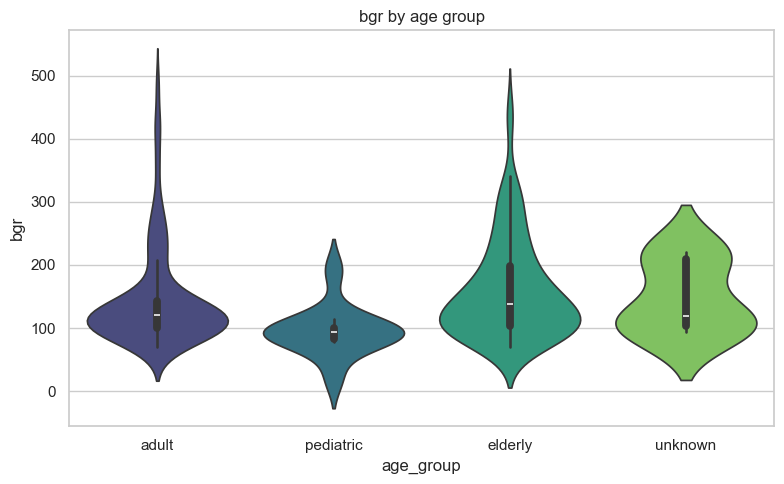

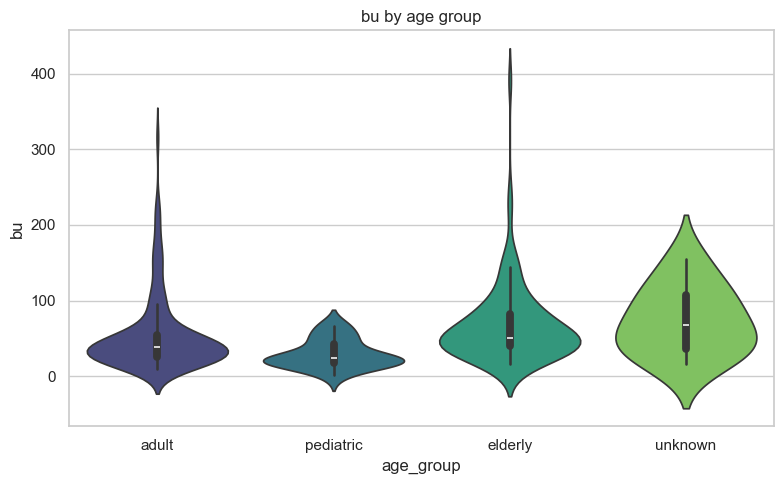

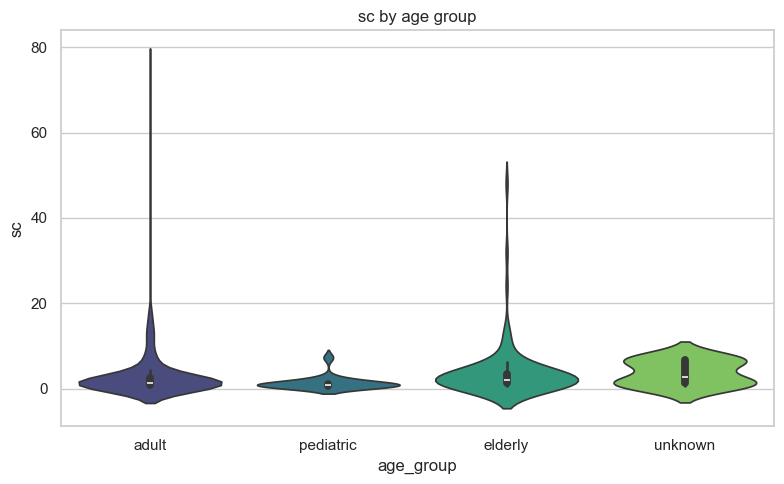

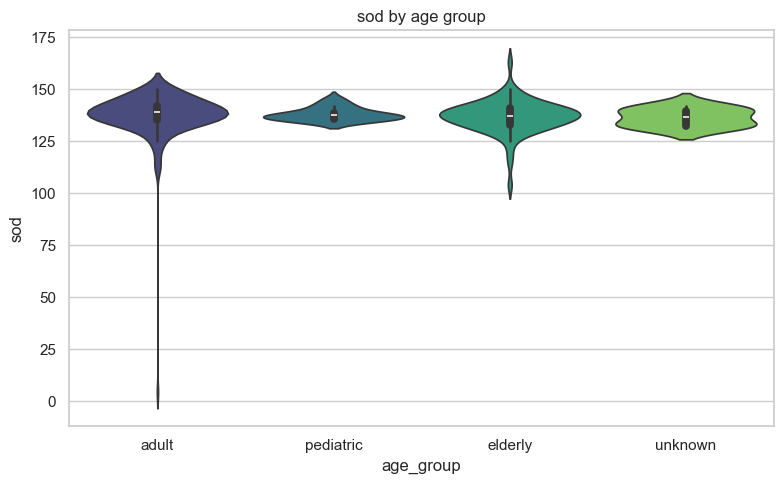

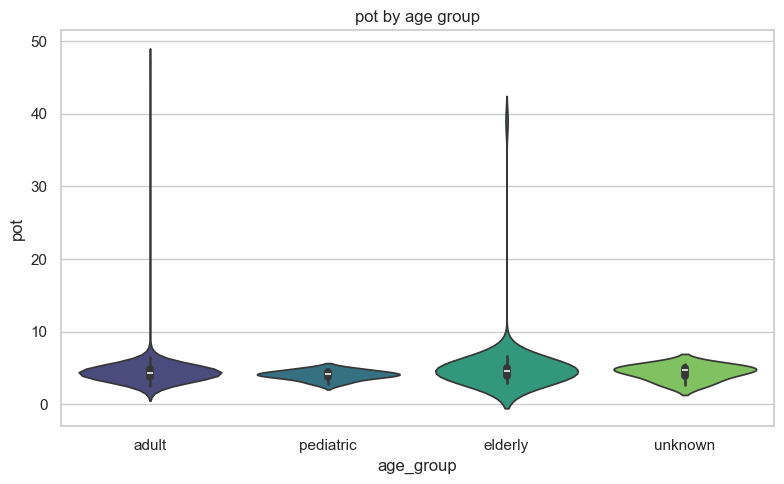

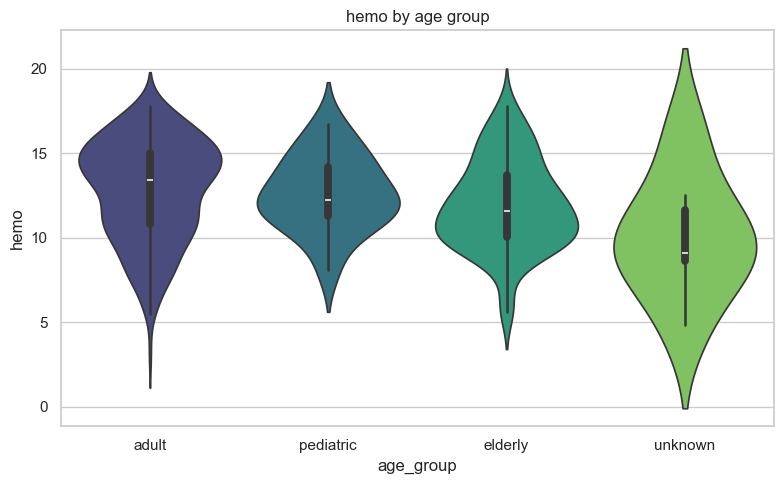

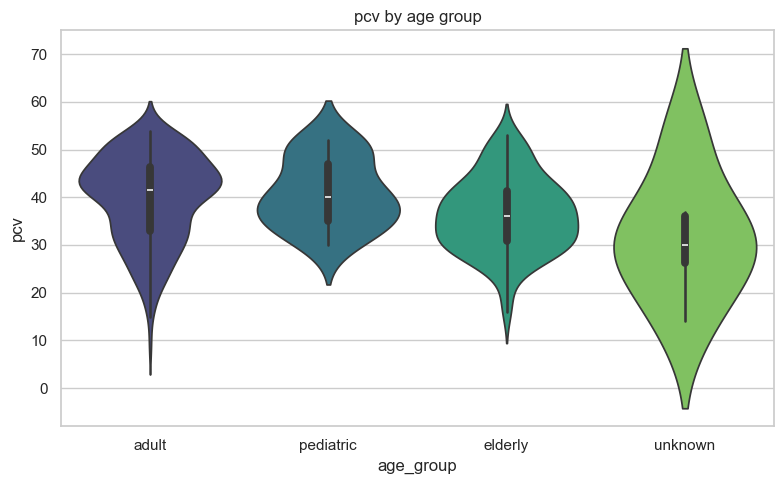

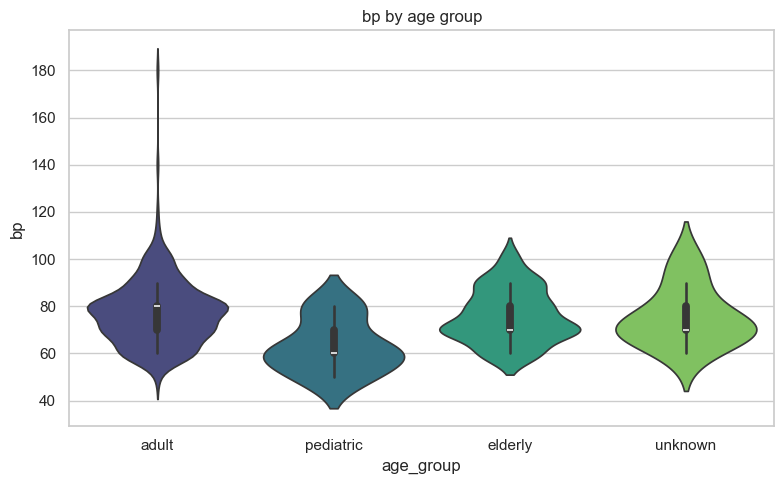

In [6]:
def age_bin(a):
    if pd.isna(a): return 'unknown'
    if a < 18: return 'pediatric'
    if a < 65: return 'adult'
    return 'elderly'

df['age_group'] = df['age'].apply(age_bin)

key_labs = ['bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'bp']
for col in key_labs:
    fig = viz.violin_by_group(df, col, 'age_group', title=f'{col} by age group')
    plt.savefig(FIGDIR / f'violin_{col}_by_age.png', dpi=120, bbox_inches='tight')
    plt.show()

## 4. Numeric correlations

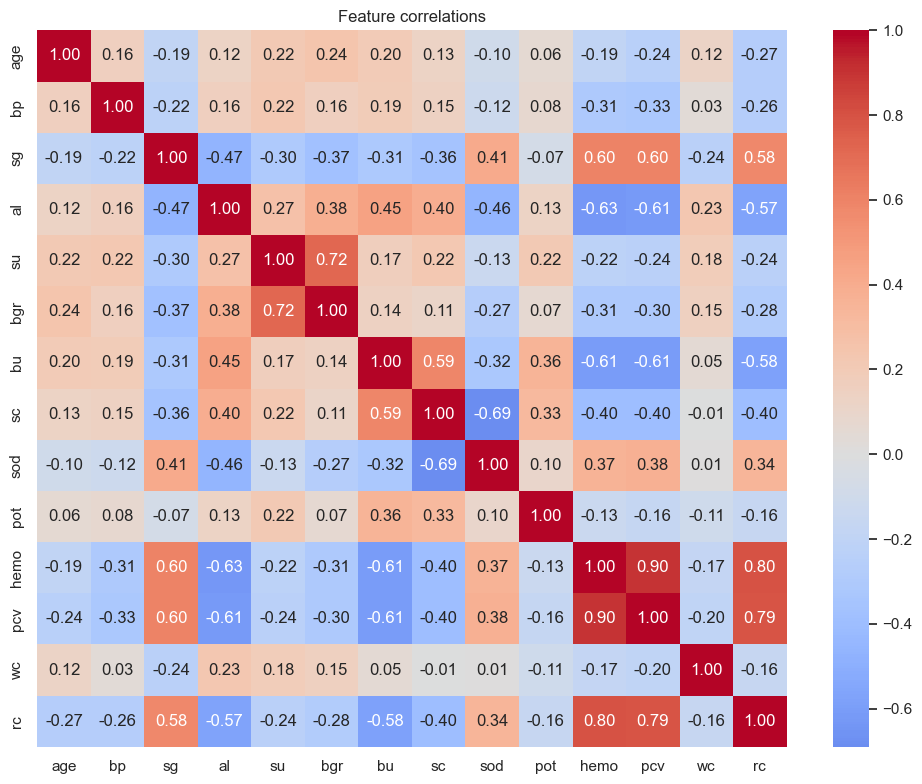

In [7]:
fig = viz.correlation_heatmap(df, list(NUMERIC_COLS))
plt.savefig(FIGDIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Comorbidity network

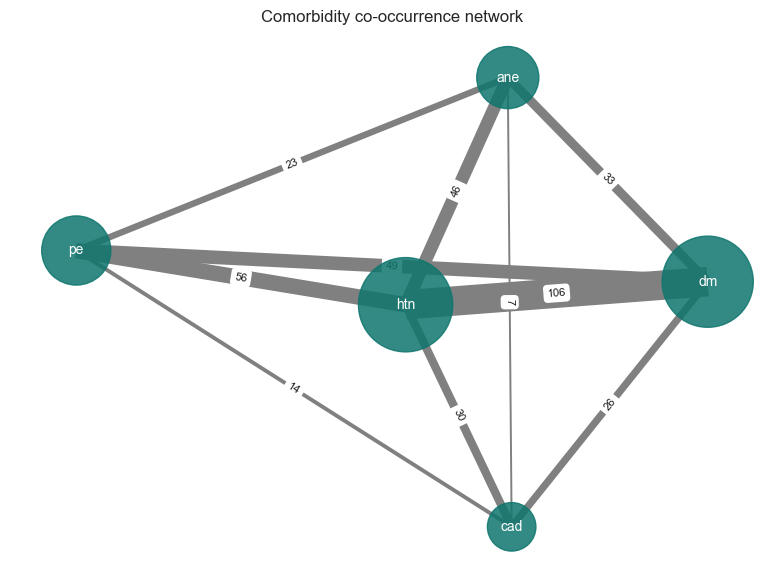

Edges (cooccurrence counts):
  htn -- dm: 106
  htn -- cad: 30
  htn -- ane: 46
  htn -- pe: 56
  dm -- cad: 26
  dm -- ane: 33
  dm -- pe: 49
  cad -- ane: 7
  cad -- pe: 14
  ane -- pe: 23


In [8]:
# Need binary-encoded conditions
df_enc = encode_binary(df)
conditions = ['htn', 'dm', 'cad', 'ane', 'pe']
fig, G = viz.comorbidity_network(df_enc, conditions, save_path=FIGDIR / 'comorbidity_network.png')
plt.show()
print('Edges (cooccurrence counts):')
for u, v, d in G.edges(data=True):
    print(f'  {u} -- {v}: {d["weight"]}')

## 6. Class balance (held-out outcome)

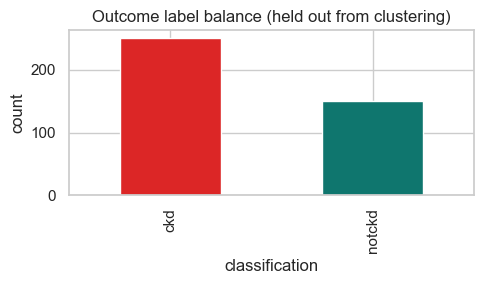

In [9]:
fig, ax = plt.subplots(figsize=(5, 3))
df_enc['classification'].value_counts().rename({1:'ckd', 0:'notckd'}).plot.bar(ax=ax, color=['#DC2626', '#0F766E'])
ax.set_title('Outcome label balance (held out from clustering)')
ax.set_ylabel('count')
plt.tight_layout()
plt.savefig(FIGDIR / 'class_balance.png', dpi=150)
plt.show()

## 7. EDA summary

Key findings recorded in `reports/figures/m1_eda_summary.md` for inclusion in the final report.
Decisions:
- Missing-value strategy: htn-stratified median (numerics) + mode (binaries) — see `src/preprocessing.impute_clinical`.
- Outliers: flagged with `<col>_outlier_flag`, not removed.
- No `sex` column → stratification falls back to age × htn.
- No height/weight → BMI cannot be computed; will use age × egfr / age × hemo interactions in M2 instead.
